In [ ]:
# Run all the cell by one click
%run -i 'Mohamed Mahrous - Assignment_2.ipynb'


# Introduction

Band gap is a crucial electronic property of materials, therefore, it is essential for determining their potential applications in fields like electronics, semiconductors, and photovoltaics. The band gap influences electrical conductivity and optical behavior, making it a key parameter for materials researchers. Given the complexity of material structures and their associated properties, clustering using unsupervised machine learning provides a promising approach for predicting band gaps based on structural and compositional data. By grouping materials with similar properties, we can derive insights into material characteristics that correlate with specific band gap values, aiding the discovery of new functional materials.

To achieve this, I applied a structured series of data preparation steps. Featurization was essential for transforming raw structural data into a machine-readable format, capturing important characteristics of the materials through numerical descriptors. This allowed us to represent complex material structures and compositions as meaningful features. We then performed correlation analysis to identify and remove highly correlated features, which helps reduce redundancy and improves the efficiency of the clustering algorithms. Scatter plots provided preliminary visual insights into the relationships between features and band gap values, helping to guide feature selection for clustering. Eventually, dimensionality reduction techniques like PCA, t-SNE were employed to reduce the feature space, making it feasible to visualize the high-dimensional dataset and explore potential clusters of materials with similar band gaps. Comparing the results of these techniques allowed us to understand the data structure from multiple perspectives and choose the most informative feature representation for clustering.


In [1]:
#Instaling the Matminer module and importing the matbench_mp_gap dataset
!pip install matminer

# Sets an environment variable named MATMINER_DATA to store datasets in the "data" directory
%env MATMINER_DATA data  

# Imports the pandas library, commonly used for data manipulation and analysis in Python
import pandas as pd  

# Imports the load_dataset function from the matminer.datasets module
from matminer.datasets import load_dataset  

# Imports get_all_dataset_info to fetch detailed information about a specific dataset
from matminer.datasets import get_all_dataset_info  

# Prints information about the "matbench_mp_gap" dataset, including its metadata and description
print(get_all_dataset_info("matbench_mp_gap"))  

# Loads the dataset "matbench_mp_gap" and stores it in the variable `data`
data = load_dataset("matbench_mp_gap")  

# Displays the first 5 rows of the dataset to give an overview of its structure and contents
data.head()  


# Calculate summary statistics for all numeric columns in the dataset
summary_statistics = data.describe()

# Display the summary statistics to show information like mean, standard deviation, min, max, etc., for numeric columns
print(summary_statistics)

# Print separator line for readability
print("**********************")  

# Check for any missing (NaN) values in each column of the dataset
nans = data.isna().sum()

# Display the count of NaN values for each column to understand if and where any missing data exists
print(nans)

# Load the matbench_mp_gap dataset
matbench_data = load_dataset("matbench_mp_gap")

# Display the first few rows of the dataset to check column names
print(matbench_data.head())

# Display the column names
print(matbench_data.columns)

#save the data into a csv file 
matbench_data.to_csv('matbench_data.csv', index=False)

env: MATMINER_DATA=data
Dataset: matbench_mp_gap
Description: Matbench v0.1 test dataset for predicting DFT PBE band gap from structure. Adapted from Materials Project database. Removed entries having a formation energy (or energy above the convex hull) more than 150meV and those containing noble gases. Retrieved April 2, 2019. For benchmarking w/ nested cross validation, the order of the dataset must be identical to the retrieved data; refer to the Automatminer/Matbench publication for more details.
Columns:
	gap pbe: Target variable. The band gap as calculated by PBE DFT from the Materials Project, in eV.
	structure: Pymatgen Structure of the material.
Num Entries: 106113
Reference: A. Jain*, S.P. Ong*, G. Hautier, W. Chen, W.D. Richards, S. Dacek, S. Cholia, D. Gunter, D. Skinner, G. Ceder, K.A. Persson (*=equal contributions)
The Materials Project: A materials genome approach to accelerating materials innovation
APL Materials, 2013, 1(1), 011002.
doi:10.1063/1.4812323
Bibtex citati

In [ ]:
# Import the pandas library for data manipulation and analysis
import pandas as pd

# Import the load_dataset function from matminer to load pre-existing datasets
from matminer.datasets import load_dataset

# Import DensityFeatures and GlobalSymmetryFeatures classes for structure-based feature calculations
from matminer.featurizers.structure import DensityFeatures, GlobalSymmetryFeatures

# Import MultipleFeaturizer to allow for combining multiple featurizers into a single operation
from matminer.featurizers.base import MultipleFeaturizer

# Load the "matbench_mp_gap" dataset and store it in the variable `data`
data = load_dataset("matbench_mp_gap")

# Define multiple structure-based featurizers to add density and symmetry features to the dataset
structure_featurizers = MultipleFeaturizer([
    DensityFeatures(),            # Featurizer to calculate density-based features
    GlobalSymmetryFeatures()      # Featurizer to calculate symmetry-based features
])

# Apply the defined structure featurizers to the 'structure' column in the dataset
# The featurize_dataframe method adds new feature columns to `data` based on the structure information
# ignore_errors=True ensures that any rows causing errors in featurization are skipped without stopping the code
data = structure_featurizers.featurize_dataframe(data, col_id="structure", ignore_errors=True)


MultipleFeaturizer:   0%|          | 0/106113 [00:00<?, ?it/s]

In [8]:
# Display the first few rows of the featurized dataset
print(data.head())

#save the data into a csv file 
data.to_csv('featurized_data.csv', index=False)

                                           structure  gap pbe   density  \
0  [[-0.00812638  0.02476014 -0.01698117] K, [-0....   1.3322  3.781313   
1  [[0.         1.78463544 1.78463544] Cr, [1.784...   0.0000  7.839811   
2  [[-2.13764909 -2.12540569 -2.14704542] Cs, [-6...   0.0000  3.119812   
3  [[0. 0. 0.] Si, [ 4.55195829  4.55195829 -4.55...   0.4113  4.361248   
4  [[0.    2.655 2.655] Ca, [2.655 0.    2.655] C...   0.3514  2.020551   

         vpa  packing fraction  spacegroup_num crystal_system  \
0  13.836878          1.046223             119     tetragonal   
1  11.367855          0.984973             221          cubic   
2  52.035996          0.860650               1      triclinic   
3  27.946089          0.328227             216          cubic   
4  29.944258          0.545444             221          cubic   

   crystal_system_int  is_centrosymmetric  n_symmetry_ops  
0                   4               False               8  
1                   1                T

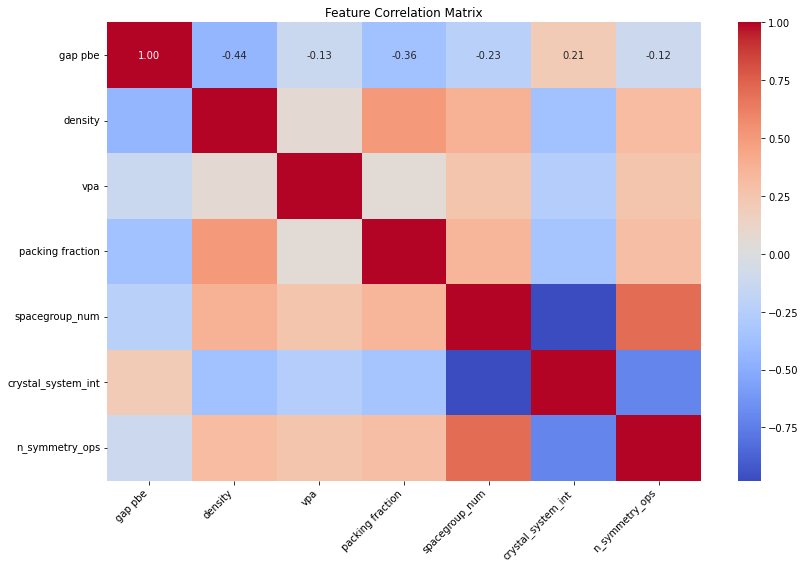

Reduced data saved to 'reduced_data.csv'
   gap pbe   density        vpa  packing fraction  spacegroup_num  \
0   1.3322  3.781313  13.836878          1.046223             119   
1   0.0000  7.839811  11.367855          0.984973             221   
2   0.0000  3.119812  52.035996          0.860650               1   
3   0.4113  4.361248  27.946089          0.328227             216   
4   0.3514  2.020551  29.944258          0.545444             221   

   crystal_system_int  n_symmetry_ops  
0                   4               8  
1                   1              96  
2                   7               1  
3                   1              48  
4                   1              96  


In [121]:
# Import pandas for data manipulation, seaborn for statistical data visualization, and matplotlib for plotting
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset from 'featurized_data.csv' into a DataFrame called `data`
data = pd.read_csv('featurized_data.csv')

# Select only numeric columns from the dataset to calculate the correlation matrix, excluding non-numeric columns
numeric_data = data.select_dtypes(include=[float, int])

# Calculate the correlation matrix for the numeric data to show correlations between features
correlation_matrix = numeric_data.corr()

# Visualize the correlation matrix with a heatmap to easily identify highly correlated features
plt.figure(figsize=(12, 8))  # Set the figure size for clarity
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)  # Use 'coolwarm' color map for contrast, cbar=True to show color bar
plt.title('Feature Correlation Matrix')  # Set the title for the plot
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
plt.yticks(rotation=0)  # Rotate y-axis labels for better visibility
plt.tight_layout()  # Adjust layout to make room for label rotation
plt.show()  # Display the heatmap

# Define a threshold for high correlation (above 0.9)
threshold = 0.9

# Drop the identified highly correlated columns from the dataset
data_reduced = numeric_data.drop(columns=to_drop)

# Save the reduced dataset with fewer features to a new CSV file, 'reduced_data.csv'
data_reduced.to_csv('reduced_data.csv', index=False)

# Confirm the reduced data has been saved and display the first few rows of `data_reduced`
print("Reduced data saved to 'reduced_data.csv'")
print(data_reduced.head())


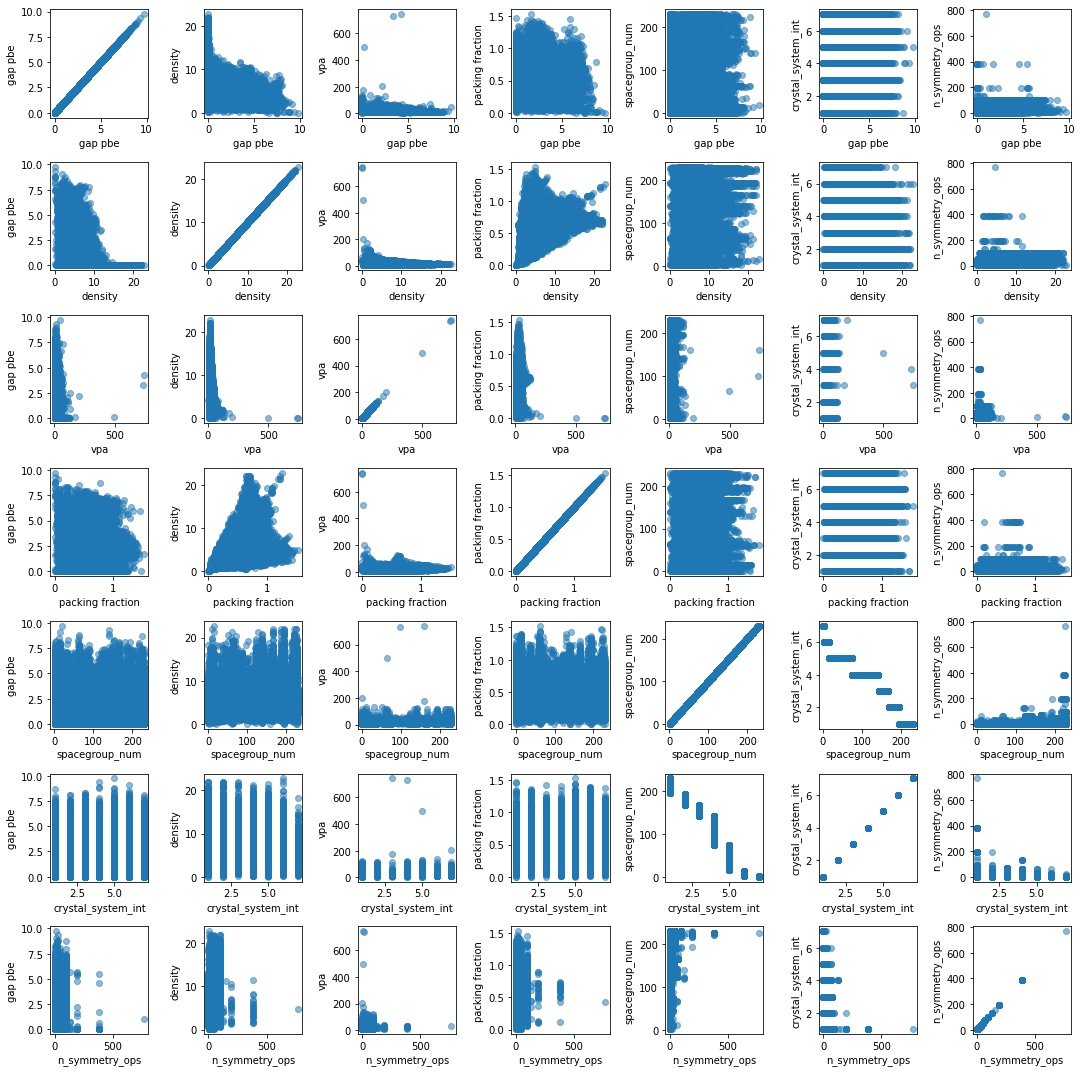

In [92]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df_reduced = pd.read_csv("reduced_data.csv")

# Select only numeric data from the first 6 columns
numeric_data = df_reduced.iloc[:, :7].select_dtypes(include='number')

# List of numeric columns to create scatter plots for
numeric_columns = numeric_data.columns

# Define the number of features
num_features = len(numeric_columns)

# Create a grid of scatter plots
fig, axes = plt.subplots(num_features, num_features, figsize=(15, 15))

# Create scatter plots in a grid
for i, x_feature in enumerate(numeric_columns):
    for j, y_feature in enumerate(numeric_columns):
        axes[i, j].scatter(numeric_data[x_feature], numeric_data[y_feature], alpha=0.5)
        axes[i, j].set_xlabel(x_feature)
        axes[i, j].set_ylabel(y_feature)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


Reduced Data:
   gap pbe   density        vpa  packing fraction  spacegroup_num  \
0   1.3322  3.781313  13.836878          1.046223             119   
1   0.0000  7.839811  11.367855          0.984973             221   
2   0.0000  3.119812  52.035996          0.860650               1   
3   0.4113  4.361248  27.946089          0.328227             216   
4   0.3514  2.020551  29.944258          0.545444             221   

   crystal_system_int  n_symmetry_ops  
0                   4               8  
1                   1              96  
2                   7               1  
3                   1              48  
4                   1              96  
gap pbe               float64
density               float64
vpa                   float64
packing fraction      float64
spacegroup_num          int64
crystal_system_int      int64
n_symmetry_ops          int64
dtype: object


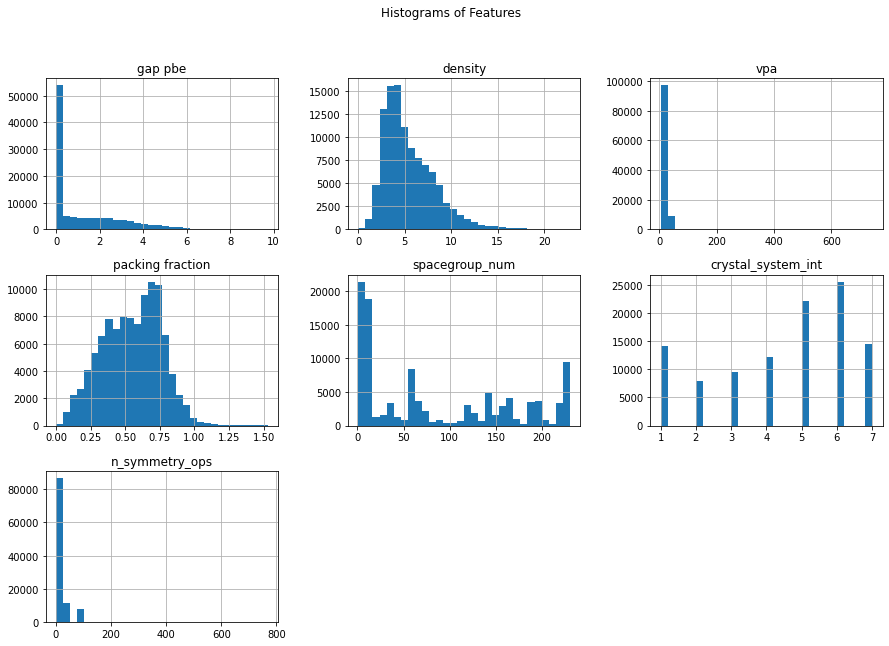

In [111]:
# Import the pandas library for data manipulation and analysis
import pandas as pd

# Import seaborn for statistical data visualization
import seaborn as sns

# Import matplotlib.pyplot for creating visualizations
import matplotlib.pyplot as plt

# Import PCA (Principal Component Analysis) from sklearn for dimensionality reduction
from sklearn.decomposition import PCA

# Load the data from the 'reduced_data.csv' file into a DataFrame
data_reduced = pd.read_csv('reduced_data.csv')

# Load the data from the 'featurized_data.csv' file into another DataFrame
data_full = pd.read_csv('featurized_data.csv')

# Ensure that data_reduced contains only numeric columns by selecting appropriate types
data_reduced = data_reduced.select_dtypes(include=[float, int])

# Print a message to indicate the beginning of the reduced data display
print("Reduced Data:")

# Display the first few rows of the reduced DataFrame for inspection
print(data_reduced.head())

# Display the data types of the columns in the reduced DataFrame
print(data_reduced.dtypes)

# Check if data_reduced is not empty before plotting histograms
if not data_reduced.empty:
    # Create histograms for the features in the reduced DataFrame
    data_reduced.hist(bins=30, figsize=(15, 10))

    # Set the title for the histogram plots
    plt.suptitle('Histograms of Features')

    # Show the histogram plots
    plt.show()
else:
    # Print a message if there are no numerical columns available for plotting
    print("No numerical columns available for histogram plotting.")


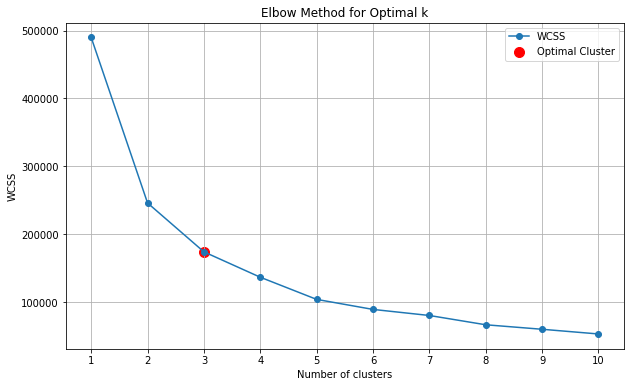

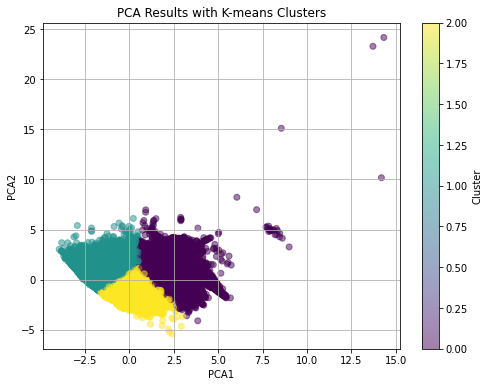

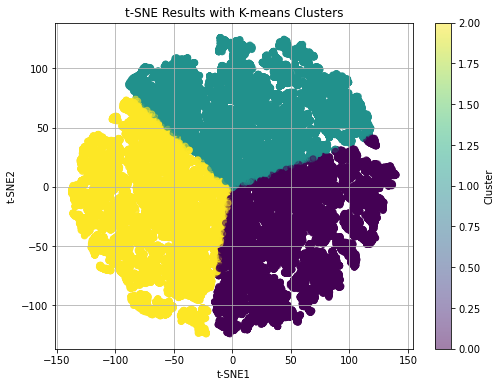

In [112]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# Assuming pca_result is already defined from previous PCA steps
if 'pca_result' in locals():
    # Initialize a list to hold the Within-Cluster Sum of Squares (WCSS) values
    wcss = []

    # Define the range of clusters to evaluate (1 to 10 in this case)
    cluster_range = range(1, 11)  # Adjust as needed
    
    # Loop through the defined cluster range to calculate WCSS for each n_clusters
    for n_clusters in cluster_range:
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        kmeans.fit(pca_result)
        wcss.append(kmeans.inertia_)  # Inertia is the WCSS

    # Define the optimal number of clusters (change this manually based on the elbow)
    optimal_clusters = 3  # Adjust this to the optimal cluster number based on the elbow

    # Plot the elbow graph
    plt.figure(figsize=(10, 6))
    plt.plot(cluster_range, wcss, marker='o', label='WCSS')

    # Highlight the optimal cluster point with a red circle
    plt.scatter(optimal_clusters, wcss[optimal_clusters - 1], color='red', s=100, label='Optimal Cluster')

    # Add plot labels and title
    plt.title('Elbow Method for Optimal k')
    plt.xlabel('Number of clusters')
    plt.ylabel('WCSS')
    plt.xticks(cluster_range)
    plt.grid()
    plt.legend()  # Show the legend for the optimal cluster

    # Display the elbow plot
    plt.show()

else:
    print("PCA result is not defined. Skipping clustering step.")
    



# Summary

The featurization process initiated with the `MultipleFeaturizer` performed using the `DensityFeatures` and `GlobalSymmetryFeatures` classes added several new columns to the dataset, expanding it from the original two columns (`gap` and `structure`) to include the following additional features which were chosen to enhance the dataset's descriptive power regarding the materials' structural and physical properties. The Density (vpa) feature provides insights into atomic packing and influences properties such as strength and thermal conductivity. The Packing Fraction offers a dimensionless measure of material density, which is relevant for applications in structural engineering. The Spacegroup_num captures the symmetry of the crystal structure, aiding in the understanding of electronic properties and phase behavior. Lastly, the Crystal_system categorizes materials based on their geometric arrangement, impacting various physical behaviors. Collectively, these features are critical for improving predictive modeling related to the materials' band gap and other relevant characteristics.

From the features correlation matrix visualisation we found that the band gap exhibits a negative correlation with crystal density, packing fraction, and space group, while showing a positive correlation with the crystal system. When examining the scatter plot between band gap and density, a negative trend appears for certain structures, while others show no clear trend. In contrast, for the crystal system, each system spans a wide range of band gap values, indicating that it cannot reliably be used to predict the band gap. After applying dimensionality reduction via PCA and t-SNE to get rid of the redundant data then We examined different values for the number of clusters (K) to optimize cluster cohesion and separation, which found to be 3 here after plottitng elbow plot, then we did interpreting the resulting clusters to understand material groupings in relation to band gap characteristics.
